In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from gender_detection import GenderDetector

In [2]:
RANDOM = 42

In [3]:
X_tx = pd.read_csv("dataset/train_transactions.csv", engine="python")
X = pd.read_csv("dataset/train_users.csv", index_col='id_user')

In [4]:
X_tx['timestamp_tr_dt'] = pd.to_datetime(X_tx['timestamp_tr'], format='mixed')
X['timestamp_reg_dt'] = pd.to_datetime(X['timestamp_reg'], format='mixed')

In [5]:
CURRENCY_USD_EXCHANGE_RATES = {
    'USD': 1,
    'EUR': 0.87,
    'GBP': 0.75
}

exchange_rates = X_tx['currency'].map(CURRENCY_USD_EXCHANGE_RATES)
X_tx['amount_usd'] = X_tx['amount'] / exchange_rates

In [6]:
gender_detector = GenderDetector()

unique_names = X_tx['card_holder'].dropna().str.lower().drop_duplicates()
name_genders = unique_names.map(gender_detector.detect_gender)
X_tx['card_holder_gender'] = X_tx['card_holder'].str.lower().map(pd.Series(name_genders.values, index=unique_names.values))

In [7]:
X_tx['country_mismatch'] = X_tx['card_country'] != X_tx['payment_country']
X_tx['no_cardholder'] = X_tx['card_holder'].isna()
X_tx['invalid_cardholder'] = ~X_tx['card_holder'].fillna('').str.contains(' ')
# check cardholder name
card_nusers = X_tx.groupby('card_mask_hash')['id_user'].nunique()
card_nuses = X_tx.groupby('card_mask_hash')['id_user'].size()
X_tx['card_nusers'] = X_tx['card_mask_hash'].map(card_nusers)
X_tx['card_nuses'] = X_tx['card_mask_hash'].map(card_nuses)
X_tx['card_holder_normalized'] = X_tx['card_holder'].str.lower()

grp = X_tx.groupby('id_user')

X['card_holder_has_male_gender'] = X_tx.assign(d=X_tx['card_holder_gender'] == 'male').groupby('id_user')['d'].any()
X['card_holder_has_female_gender'] = X_tx.assign(d=X_tx['card_holder_gender'] == 'female').groupby('id_user')['d'].any()
X['card_holder_rate_male_gender'] = X_tx.assign(d=X_tx['card_holder_gender'] == 'male').groupby('id_user')['d'].mean()
X['card_holder_rate_female_gender'] = X_tx.assign(d=X_tx['card_holder_gender'] == 'female').groupby('id_user')['d'].mean()
X['is_male'] = X['gender'] == 'male'
X['gender_card_holder_mismatch'] = (X['is_male'] & X['card_holder_has_female_gender']) | (~X['is_male'] & X['card_holder_has_male_gender'])

X['email_domain'] = X['email'].str.split('@').str[1]
X['first_tx_time'] = grp['timestamp_tr_dt'].min()
X['last_tx_time'] = grp['timestamp_tr_dt'].max()
X['tx_cnt'] = grp.size()

X['ncurrency'] = grp['currency'].nunique()
X['ncard_holders'] = grp['card_holder_normalized'].nunique()
X['ncards'] = grp['card_mask_hash'].nunique()
X['ncard_country'] = grp['card_country'].nunique()
X['ntx_type'] = grp['transaction_type'].nunique()
X['npayment_country'] = grp['payment_country'].nunique()
X['country_mismatch_rate'] = grp['country_mismatch'].mean()
X['total_amount'] = grp['amount_usd'].sum()
X['min_amount'] = grp['amount_usd'].min()
X['max_amount'] = grp['amount_usd'].max()
X['mean_amount'] = grp['amount_usd'].mean()
X['std_amount'] = grp['amount_usd'].std()
X['no_cardholder_rate'] = grp['no_cardholder'].mean()
X['invalid_cardholder_rate'] = grp['invalid_cardholder'].mean()
X['reg_card_country_mismatch'] = X_tx.assign(d=X_tx['id_user'].map(X['reg_country']) == X_tx['payment_country']).groupby('id_user')['d'].any()

X['card_more_nusers'] = X_tx.assign(d=X_tx['card_nusers'] > 1).groupby('id_user')['d'].any()
X['card_more_nusers'] = X_tx.assign(d=X_tx['card_nusers'] > 1).groupby('id_user')['d'].any()

X['fail_rate'] = X_tx.assign(d=X_tx['status'] == 'fail').groupby('id_user')['d'].mean()
X['no_card_country_rate'] = X_tx.assign(d=X_tx['card_country'].isna()).groupby('id_user')['d'].mean()
X['no_payment_country_rate'] = X_tx.assign(d=X_tx['payment_country'].isna()).groupby('id_user')['d'].mean()
X['card_type_prepaid_rate'] = X_tx.assign(d=X_tx['card_type'] == 'PREPAID').groupby('id_user')['d'].mean()
X['card_type_debit_rate'] = X_tx.assign(d=X_tx['card_type'] == 'DEBIT').groupby('id_user')['d'].mean()
X['card_type_credit_rate'] = X_tx.assign(d=X_tx['card_type'] == 'CREDIT').groupby('id_user')['d'].mean()
error_groups = X_tx['error_group'].dropna().unique().tolist()
# error_groups = ['antifraud', 'fraud']
for error_group in error_groups:
    X['err_rate_' + error_group] = X_tx.assign(d=X_tx['error_group'] == error_group).groupby('id_user')['d'].mean()

X['total_tx_time'] = (X['last_tx_time'] - X['first_tx_time']).dt.total_seconds() / 3600 / 24
X['tx_rate'] = X['tx_cnt'] / X['total_tx_time']
X['tx_rate'] = X['tx_rate'].replace(np.inf, 0)
X['tx_time_since_reg'] = (X['first_tx_time'] - X['timestamp_reg_dt']).dt.total_seconds() / 3600

In [8]:
X

,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,timestamp_reg_dt,card_holder_has_male_gender,card_holder_has_female_gender,card_holder_rate_male_gender,...,err_rate_issuer decline,err_rate_limit exceeded error,err_rate_technical issue,err_rate_decline (other),err_rate_expired error,err_rate_token error,err_rate_user decline,total_tx_time,tx_rate,tx_time_since_reg
id_user,,,,,,,,,,,,,,,,,,,,,
15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,0.337687,...,0.022388,0.0,0.0,0.007463,0.000000,0.0,0.0,130.088009,4.120288,1.338925
9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0,2025-05-04 19:30:02.902877+00:00,True,True,0.923077,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,113.061447,0.459927,3059.263916
21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0,2025-09-07 18:24:51+00:00,True,False,0.714286,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.650995,10.752765,0.324444
61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1,2025-01-01 17:33:08.026088+00:00,True,False,1.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.617836,12.948415,2.226521
13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0,2025-06-21 18:27:03.420098+00:00,False,True,0.000000,...,0.000000,0.0,0.0,0.019608,0.039216,0.0,0.0,187.386875,0.544328,13.211828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15208750,2025-07-15 00:09:30.100536+00:00,alexpaterson@gmail.com,male,United States,cpa,0,2025-07-15 00:09:30.100536+00:00,False,False,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,21.605805
34511422,2025-12-22 16:25:42+00:00,kmiller216@gmail.com,male,United States,ppc,0,2025-12-22 16:25:42+00:00,True,False,1.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.215278
28313259,2025-11-04 17:41:08+00:00,vams25@gmail.com,male,United States,ppc,0,2025-11-04 17:41:08+00:00,True,False,1.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.300556


In [9]:
categorical_pipe = Pipeline(
    [
        ("ohe", OneHotEncoder()),
    ]
)

encode = ColumnTransformer(
    [
        ("bool", "passthrough", ["reg_card_country_mismatch", "card_more_nusers", 'is_male']),
        (
            "num",
            "passthrough",
            [
                "ncard_holders",
                "no_cardholder_rate",
                "invalid_cardholder_rate",
                "ncards",
                "ncard_country",
                "npayment_country",
                "tx_cnt",
                "tx_rate",
                "total_tx_time",
                "tx_time_since_reg",
                "country_mismatch_rate",
                "total_amount",
                "mean_amount",
                "ntx_type",
                "min_amount",
                "max_amount",
                "card_type_prepaid_rate",
                "card_type_debit_rate",
                "card_type_credit_rate",
                "no_card_country_rate",
                "no_payment_country_rate",
                "card_holder_rate_male_gender",
                "card_holder_rate_female_gender",
                "fail_rate",
                "ncurrency",
                "gender_card_holder_mismatch",
                *["err_rate_" + eg for eg in error_groups],
            ],
        ),
        ("cat", categorical_pipe, ["reg_country", "traffic_type", "email_domain"]),
    ]
)

Xp = encode.fit_transform(X)
y = X["is_fraud"]
Xp

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8686549 stored elements and shape (395381, 272)>

In [10]:
indices = np.arange(Xp.shape[0])
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(Xp, y, indices, test_size=0.2, stratify=y, random_state=RANDOM)

In [11]:
model = LGBMClassifier(n_estimators=300, learning_rate=0.1, random_state=RANDOM)
# model = XGBClassifier(
#     scale_pos_weight=19,
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     eval_metric='aucpr',
#     random_state=42
# )
# model = CatBoostClassifier(
#     iterations=500,
#     learning_rate=0.1,
#     depth=10,
# )
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11946, number of negative: 304358
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8029
[LightGBM] [Info] Number of data points in the train set: 316304, number of used features: 225
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.037767 -> initscore=-3.237808
[LightGBM] [Info] Start training from score -3.237808


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


/home/user/.cache/pypoetry/virtualenvs/ucu-audio-processing-course-s7K5_All-py3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC: 0.9910
Confusion matrix:
[[74457  1634]
 [  317  2669]]
Accuracy: 0.975, F1: 0.732


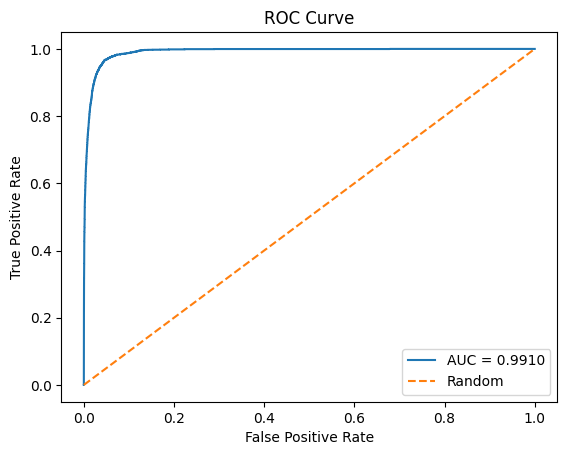

In [12]:
probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probs)
print(f"ROC AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

THRESHOLD = 0.2
preds = (probs > THRESHOLD).astype(int)

cm = confusion_matrix(y_test, preds)
print('Confusion matrix:')
print(cm)

print(f"Accuracy: {accuracy_score(y_test, preds):.3f}, F1: {f1_score(y_test, preds):.3f}")

In [13]:
X['probs'] = model.predict_proba(Xp)[:, 1]

/home/user/.cache/pypoetry/virtualenvs/ucu-audio-processing-course-s7K5_All-py3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
X[(X['is_fraud'] == 0) & (X['err_rate_fraud'] > 0) & (X['gender_card_holder_mismatch'])].iloc[100:300]

,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,timestamp_reg_dt,card_holder_has_male_gender,card_holder_has_female_gender,card_holder_rate_male_gender,...,err_rate_limit exceeded error,err_rate_technical issue,err_rate_decline (other),err_rate_expired error,err_rate_token error,err_rate_user decline,total_tx_time,tx_rate,tx_time_since_reg,probs
id_user,,,,,,,,,,,,,,,,,,,,,
32306475,2025-12-06 20:15:44+00:00,marcusthorneK@gmail.com,male,Argentina,ppc,0,2025-12-06 20:15:44+00:00,True,True,0.876712,...,0.0,0.0,0.0,0.00,0.0,0.0,23.795093,3.067859,29.558333,0.176737
24660902,2025-10-07 08:33:18+00:00,ktmbda13@gmail.com,female,Bermuda,ppc,0,2025-10-07 08:33:18+00:00,True,False,1.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,40.633727,1.304335,4.326389,0.004401
16021629,2025-07-22 20:56:07.225264+00:00,millersarah@hotmail.com,male,Sweden,ppc,0,2025-07-22 20:56:07.225264+00:00,False,True,0.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,150.529155,0.365378,166.867160,0.302348
7988061,2025-04-15 18:28:54.577560+00:00,sarahjenk2@gmail.com,male,Trinidad and Tobago,ppc,0,2025-04-15 18:28:54.577560+00:00,False,True,0.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,107.759479,0.714554,3624.652895,0.045835
28439558,2025-11-05 16:45:39+00:00,liamanderson@gmail.com,female,Cyprus,cpa,0,2025-11-05 16:45:39+00:00,True,False,1.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,50.480243,1.287632,0.428611,0.160847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17878739,2025-08-09 17:50:15+00:00,bakerrossi58@gmail.com,male,Germany,ppc,0,2025-08-09 17:50:15+00:00,False,True,0.000000,...,0.0,0.0,0.0,0.25,0.0,0.0,39.049271,0.204869,1244.590000,0.130120
35467796,2025-12-28 00:41:18+00:00,julianvance@gmail.com,female,Saint Lucia,ppc,0,2025-12-28 00:41:18+00:00,True,False,1.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,0.000000,0.000000,0.737500,0.367512
927957,2025-01-11 12:50:30.181697+00:00,liamd-@hotmail.com,female,Sweden,cpa,0,2025-01-11 12:50:30.181697+00:00,True,False,1.000000,...,0.0,0.0,0.0,0.00,0.0,0.0,0.111390,17.954903,0.204152,0.110310


In [15]:
h = X.iloc[idx_test[(preds == 0) & (y_test == 1)]]
h = h[h['tx_cnt'] == 1]
h = h.sort_values('probs')
h

,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,timestamp_reg_dt,card_holder_has_male_gender,card_holder_has_female_gender,card_holder_rate_male_gender,...,err_rate_limit exceeded error,err_rate_technical issue,err_rate_decline (other),err_rate_expired error,err_rate_token error,err_rate_user decline,total_tx_time,tx_rate,tx_time_since_reg,probs
id_user,,,,,,,,,,,,,,,,,,,,,
35013246,2025-12-25 18:42:43+00:00,cmuller884@gmail.com,female,Gabon,ppc,1,2025-12-25 18:42:43+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.520556,0.000019
8722501,2025-04-25 04:57:15.464672+00:00,markmiller41@gmail.com,female,Australia,ppc,1,2025-04-25 04:57:15.464672+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.301260,0.002952
27898752,2025-11-01 16:54:41+00:00,dadrobjenkinsons@gmail.com,female,United Kingdom,ppc,1,2025-11-01 16:54:41+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.883056,0.004088
7576959,2025-04-10 20:06:44.137541+00:00,linda.rodriguez12@gmail.com,male,Australia,cpa,1,2025-04-10 20:06:44.137541+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.124684,0.004170
3997961,2025-02-22 01:04:23.791467+00:00,johnhwilliams85@gmail.com,male,United Kingdom,cpa,1,2025-02-22 01:04:23.791467+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,694.915613,0.004375
11770352,2025-06-03 21:53:46.885341+00:00,sarahjenkins@gmail.com,female,United States,ppc,1,2025-06-03 21:53:46.885341+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.225865,0.004553
12470781,2025-06-12 23:10:38.838785+00:00,bren5932@gmail.com,male,United States,organic,1,2025-06-12 23:10:38.838785+00:00,True,False,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.432267,0.005813
28203752,2025-11-03 22:09:50+00:00,sophiemartin@gmail.com,female,France,ppc,1,2025-11-03 22:09:50+00:00,True,False,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.205556,0.007466
14146021,2025-07-03 11:21:55.818943+00:00,roberttom066@gmail.com,male,New Zealand,cpa,1,2025-07-03 11:21:55.818943+00:00,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.488106,0.007644


In [16]:
X_tx.loc[X_tx['payment_country'].isna(), 'id_user'].map(X['is_fraud']).mean()

0.20539878731343283

In [17]:
# hg = X[X['tx_cnt'] == 1]
hg = X
hb = hg.merge(X_tx[X_tx['id_user'].isin(hg.index)], on='id_user', how='left')
hb

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,timestamp_reg_dt,card_holder_has_male_gender,card_holder_has_female_gender,...,payment_country,timestamp_tr_dt,amount_usd,card_holder_gender,country_mismatch,no_cardholder,invalid_cardholder,card_nusers,card_nuses,card_holder_normalized
0,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,...,Sweden,2025-09-06 07:45:39+00:00,4.379310,unknown,False,False,False,1.0,181.0,johansson lars
1,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,...,Sweden,2025-08-02 01:58:19+00:00,4.344828,male,False,False,False,1.0,55.0,lars johansson
2,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,...,Sweden,2025-08-12 18:10:42+00:00,9.183908,unknown,False,False,False,1.0,181.0,johansson lars
3,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,...,Sweden,2025-09-27 00:12:01+00:00,17.287356,unknown,False,False,False,1.0,139.0,johansson lars
4,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,2025-07-16 19:01:23.868869+00:00,True,False,...,Sweden,2025-07-22 13:20:29+00:00,17.275862,male,False,False,False,1.0,13.0,lars johansson
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135373,15208750,2025-07-15 00:09:30.100536+00:00,alexpaterson@gmail.com,male,United States,cpa,0,2025-07-15 00:09:30.100536+00:00,False,False,...,United States,2025-07-15 21:45:51+00:00,3.000000,NaN,False,True,True,1.0,1.0,NaN
3135374,34511422,2025-12-22 16:25:42+00:00,kmiller216@gmail.com,male,United States,ppc,0,2025-12-22 16:25:42+00:00,True,False,...,United States,2025-12-22 16:38:37+00:00,2.080000,male,False,False,False,1.0,1.0,kevin miller
3135375,28313259,2025-11-04 17:41:08+00:00,vams25@gmail.com,male,United States,ppc,0,2025-11-04 17:41:08+00:00,True,False,...,NaN,2025-11-04 17:59:10+00:00,3.000000,male,True,False,False,2.0,10.0,lucas m vance
3135376,31685096,2025-12-01 15:28:38+00:00,lrwinpdx@gmail.com,female,United States,ppc,0,2025-12-01 15:28:38+00:00,True,False,...,United States,2025-12-10 15:41:51+00:00,2.000000,male,False,False,False,1.0,1.0,lucas ray white


In [18]:
hb.loc[(hb['error_group'] == 'fraud') & (hb['currency'] == 'USD') & (hb['payment_country'].notna() & hb['card_country'].notna()) & (hb['is_fraud'] == 1)]

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,timestamp_reg_dt,card_holder_has_male_gender,card_holder_has_female_gender,...,payment_country,timestamp_tr_dt,amount_usd,card_holder_gender,country_mismatch,no_cardholder,invalid_cardholder,card_nusers,card_nuses,card_holder_normalized
4057,15800396,2025-07-20 19:14:43.970510+00:00,j-o-h-n-s99@hotmail.com,male,Turkey,ppc,1,2025-07-20 19:14:43.970510+00:00,True,True,...,Türkiye,2025-07-20 20:04:16+00:00,2.00,female,True,False,False,1.0,1.0,clara smith
7414,2242815,2025-01-29 09:43:27.440881+00:00,carlom@gmail.com,male,Argentina,ppc,1,2025-01-29 09:43:27.440881+00:00,True,False,...,Argentina,2025-02-14 17:31:10.199757+00:00,3.00,male,False,False,False,1.0,142.0,carlos mario ramirez
7416,2242815,2025-01-29 09:43:27.440881+00:00,carlom@gmail.com,male,Argentina,ppc,1,2025-01-29 09:43:27.440881+00:00,True,False,...,Argentina,2025-11-24 17:38:12+00:00,3.00,unknown,False,False,False,1.0,61.0,ramirez carlos mario
7441,2242815,2025-01-29 09:43:27.440881+00:00,carlom@gmail.com,male,Argentina,ppc,1,2025-01-29 09:43:27.440881+00:00,True,False,...,Argentina,2025-02-14 17:42:42.394876+00:00,3.00,male,False,False,False,1.0,142.0,carlos mario ramirez
7450,2242815,2025-01-29 09:43:27.440881+00:00,carlom@gmail.com,male,Argentina,ppc,1,2025-01-29 09:43:27.440881+00:00,True,False,...,Argentina,2025-09-24 01:14:44+00:00,6.00,male,False,False,False,1.0,142.0,carlos mario ramirez
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131781,14050900,2025-07-02 07:15:29.389414+00:00,davidm249@yahoo.com,male,United States,ppc,1,2025-07-02 07:15:29.389414+00:00,False,False,...,United States,2025-07-02 07:20:24+00:00,2.00,NaN,False,True,True,1.0,1.0,NaN
3131996,19818351,2025-08-27 00:21:07+00:00,sarahmiller54@gmail.com,female,United States,organic,1,2025-08-27 00:21:07+00:00,True,False,...,United States,2025-08-27 00:54:29+00:00,2.08,male,False,False,False,1.0,1.0,david j thompson
3132395,36070994,2025-12-30 21:26:59+00:00,bwilson942@gmail.com,female,United States,cpa,1,2025-12-30 21:26:59+00:00,True,False,...,United States,2025-12-31 04:11:41+00:00,2.00,male,False,False,False,1.0,1.0,marcus evans
3132669,30647462,2025-11-22 21:05:40+00:00,Tabitha.s5821@gmail.com,male,United States,cpa,1,2025-11-22 21:05:40+00:00,False,True,...,United States,2025-11-25 05:52:27+00:00,2.09,female,False,False,False,1.0,1.0,elena rodriguez


In [19]:
hb.loc[(hb['is_fraud'] == 1) & (hb['card_type_prepaid_rate'] == 0) & (hb['npayment_country'] == 1) & (hb['fail_rate'] < 0.5)].to_csv('frauds.csv')

In [20]:
hb.loc[(hb['error_group'] == 'fraud') & (hb['currency'] == 'USD') & (hb['payment_country'].notna() & hb['card_country'].notna()) & (hb['payment_country'] == hb['card_country']) & (hb['card_country'] == hb['reg_country']) & (hb['is_fraud'] == 1), ['id_user', 'email', 'gender', 'card_holder', 'is_fraud', 'gender_card_holder_mismatch']].to_csv('frauds.csv')